In [2]:
%pip install davos
import davos

davos.config.suppress_stdout = True

Note: you may need to restart the kernel to use updated packages.


Import and install dependencies

In [3]:
smuggle numpy as np       # pip: numpy==1.24.3
smuggle pandas as pd      # pip: pandas==2.0.1
smuggle hypertools as hyp # pip: hypertools==0.8.0
smuggle seaborn as sns    # pip: seaborn==0.12.2

smuggle sklearn as sk     # pip: scikit-learn==1.2.2
from sklearn.cluster import KMeans

smuggle scipy as sp       # pip: scipy==1.10.1
from scipy.spatial.distance import pdist, cdist, squareform

from mat73 smuggle loadmat # pip: mat73==0.60

smuggle requests          # pip: requests==2.28.2
smuggle nibabel as nib    # pip: nibabel==5.1.0
smuggle timecorr as tc    # pip: git+https://github.com/ContextLab/timecorr@9d567e2
smuggle nilearn as nl     # pip: nilearn==0.10.1
from nilearn.maskers import NiftiMasker
from nilearn.plotting import plot_anat, plot_glass_brain
from bids smuggle BIDSLayout, BIDSValidator  # pip: pybids==0.16.1

from matplotlib smuggle pyplot as plt  # pip: matplotlib==3.7.1
from matplotlib import animation as ani
from tqdm smuggle tqdm    # pip: tqdm==4.64.1

import warnings
import os
import shutil
import zipfile
import pickle
from glob import glob as lsdir

from helpers import nii2cmu, cmu2nii, basedir, figdir, datadir, scratch_dir, raw_data_url, get_factors, get_weights

%matplotlib inline

/Users/jmanning/opt/anaconda3/envs/directed-forgetting-networks/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/jmanning/opt/anaconda3/envs/directed-forgetting-networks/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/jmann

Download fMRI data

In [4]:
raw_datadir = os.path.join(datadir, 'DFFR')
if not os.path.exists(raw_datadir):
    raw_zip = os.path.join(datadir, 'DFFR.zip')
    if not os.path.exists(raw_zip):
        print('Downloading raw data...')
        with open(raw_zip, 'wb') as f:
            data = requests.get(raw_data_url).content
            f.write(data)

    print('Extracting raw data...')
    with zipfile.ZipFile(raw_zip, 'r') as zip_ref:
        zip_ref.extractall(datadir)
    shutil.rmtree(os.path.join(datadir, '__MACOSX'))
    os.remove(raw_zip)

Exclude participants with incompatable data (following [Manning et al., 2016](https://link.springer.com/article/10.3758/s13423-016-1024-7?dom=AOL)):
  - 072413_DFFR_0: sync pulses were not captured correctly, resulting in incorrect timing during experiment
  - 112313_DFFR_0: participant exhibited ceiling performance, so there's no "forgetting" to measure

In [5]:
def reg_file2subj(fname):
    return os.path.split(fname)[1][:-len('_regs_results.mat')]

exclude = ['072413_DFFR_0', '112313_DFFR_0']

Load in regressors (descriptions of what's happening in the experiment at each moment of scanning) and behavioral data

In [6]:
regmats = {reg_file2subj(r): sp.io.loadmat(r)['all_regressors'][:-1, :] for r in lsdir(os.path.join(datadir, 'regressors', '*_regs_results.mat')) if reg_file2subj(r) not in exclude}
behavior = {os.path.split(r)[1][:-4]: loadmat(r) for r in lsdir(os.path.join(datadir, 'regressors', '*_0.mat')) + lsdir(os.path.join(datadir, 'regressors', '*_1.mat')) if os.path.split(r)[1][:-4] not in exclude}

Display an example regressors matrix

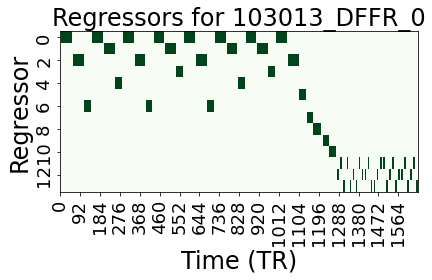

In [7]:
# display an example regressors matrix
subj = np.random.choice(list(regmats.keys()))
sns.heatmap(regmats[subj], cmap='Greens', cbar=False)
plt.title(f'Regressors for {subj}', fontsize=24)
plt.xlabel('Time (TR)', fontsize=24)
plt.ylabel('Regressor', fontsize=24);
sns.despine(top=False, right=False, left=False, bottom=False)

plt.tight_layout()

Load in description of regressors

In [8]:
reg_key = pd.read_csv(os.path.join(datadir, 'regressors', 'key.csv'))
reg_key

,block,list_id,cue,behavior,stimulus
0,1,1,NaN,present,word
1,1,2,remember,present,word
2,1,2,forget,present,word
3,1,1,remember,recall,NaN
4,1,2,remember,recall,NaN
5,1,1,forget,recall,NaN
6,1,2,forget,recall,NaN
7,2,1,NaN,present,word
8,2,1,NaN,recall,NaN
9,2,2,NaN,present,word


Display the example participant's serial position curves for remember + forget lists

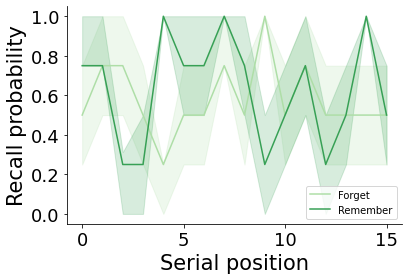

In [9]:
spc = pd.DataFrame(behavior[subj]['spc']).reset_index().rename({'index': 'List'}, axis=1).melt(id_vars='List', var_name='Serial position', value_name='Recall probability')
spc['Cue'] = spc['List'].apply(lambda x: 'Remember' if behavior[subj]['cuetype'][x] == 0 else 'Forget')

sns.lineplot(spc, x='Serial position', y='Recall probability', hue='Cue', palette='Greens', errorbar=('ci', 50));
sns.despine(top=True, right=True)
plt.legend(loc='lower right', fontsize=10)

Load in fMRI data and convert to reduced format:
  - Represent each image using $K = 250$ "nodes" (following [[Manning et al., 2018](https://www.sciencedirect.com/science/article/pii/S1053811918300715?via%3Dihub)])
  - We'll do computations on the "reduced" versions of the data to save on memory + compute power

In [25]:
# hard-code these; it's faster than fitting them "properly" using HTFA and we don't need an exact answer
K = 250
width = 25

template_fname = os.path.join(datadir, 'MNI152_T1_2mm_brain.nii.gz')
template = nii2cmu(template_fname)

Plot the template (MNI) brain

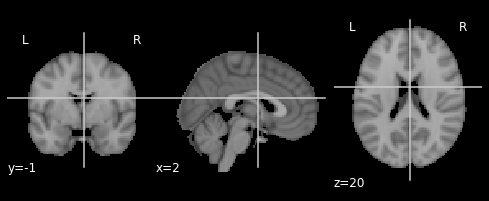

In [28]:
plot_anat(template_fname);

Scatter the $K$ nodes evenly throughout the standard MNI brain

In [23]:
kmeans = KMeans(n_clusters=K, random_state=0, n_init='auto').fit(template['R'])
centers = kmeans.cluster_centers_
widths = np.ones(K) * width

Plot the voxel (black) and node (red) locations

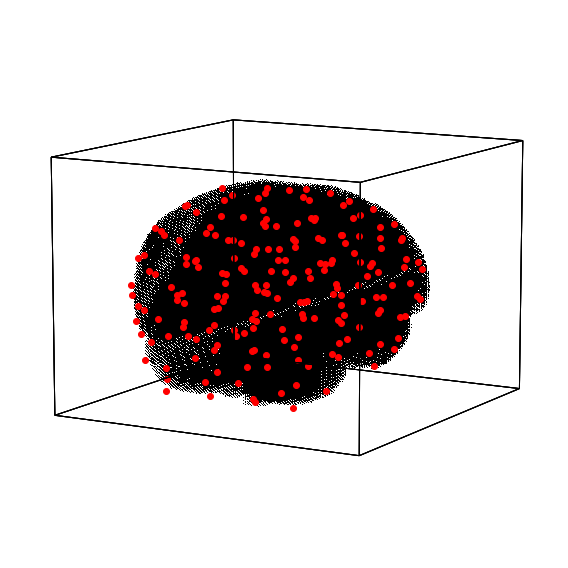

In [43]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': '3d'})
hyp.plot(template['R'], 'k,', ax=ax)
hyp.plot(centers, 'ro', ax=ax);
plt.tight_layout()

Project each participant's data onto the $K$ nodes

In [46]:
def reduce(fname, centers, widths, img=None):
    if img is None:
        img = nii2cmu(fname)
    F = get_factors(img['R'], centers, widths)
    return get_weights(img['Y'], F)

def nii_fname2subj(fname):
    return os.path.split(fname)[1][:-len('.nii.gz')]

In [45]:
nii_files = [x for x in lsdir(os.path.join(datadir, 'DFFR', '*.nii.gz')) if nii_fname2subj(x) not in exclude]
print(f'Found data for {len(nii_files)} participants.')

Found data for 23 participants.


Compute the correlations between upper triangles of the timepoints-by-timepoints correlation matrices for the original and reduced representations of the data, for each participant.

In [66]:
corrs = []
data = {}
for n in tqdm(nii_files):
    fname = os.path.join(scratch_dir, f'{nii_fname2subj(n)}_reduced_K{K}_width{width}.pkl')

    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            W, original_corrmat, reduced_corrmat = pickle.load(f)
    else:
        img = nii2cmu(n)
        W = reduce(n, centers, widths, img=img)

        # compute correlation matrices
        original_corrmat = 1 - pdist(img['Y'], metric='correlation')
        reduced_corrmat = 1 - pdist(W, metric='correlation')

        with open(fname, 'wb') as f:
            pickle.dump([W, original_corrmat, reduced_corrmat], f)

    corrs.append(np.corrcoef(original_corrmat, reduced_corrmat)[0, 1])
    data[nii_fname2subj(n)] = W

100%|██████████| 23/23 [00:00<00:00, 118.69it/s]


Plot histogram of correlation coefficients between original vs. reduced correlation matrices

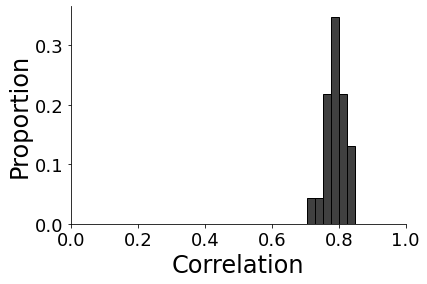

In [63]:
sns.histplot(corrs, color='k', stat='proportion')
plt.xlabel('Correlation', fontsize=24)
plt.ylabel('Proportion', fontsize=24)
plt.xlim([0, 1])
sns.despine(top=True, right=True);

Another sanity check: make sure voxel locations align across participants (and with the template brain)

In [64]:
coords = [template['R']]

for n in nii_files:
    img = nii2cmu(n)
    coords.append(img['R'])

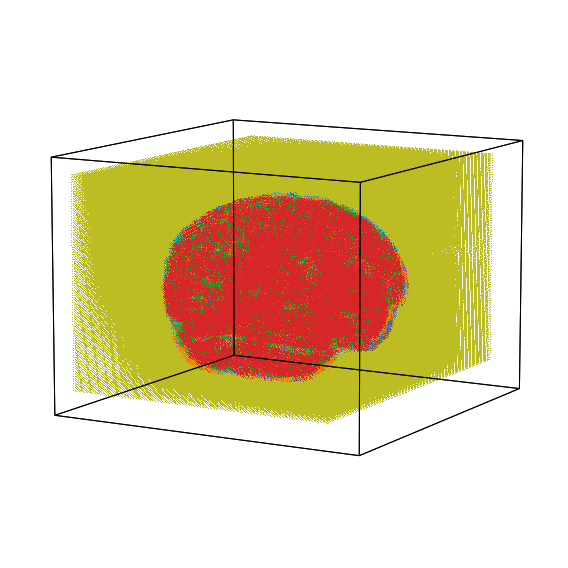

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(projection='3d'))
x = hyp.plot(coords, ',', ax=ax)

Everything below here is broken (based on an old approach to these analyses).  With some cleanup it may work...

In [8]:
def package_data(masked_data, nii_files, regressor_files):
    nii_subjs = list(map(lambda f: f.split('/')[-1][:-len('.nii')], nii_files))
    reg_subjs = list(map(lambda f: f.split('/')[-1][:-len('_regs_results.mat')], regressor_files))
    
    data = []
    for i, s in enumerate(nii_subjs):
        try:
            j = np.ravel(np.where(np.array(list(map(lambda x: x == s, reg_subjs)))))[0]
            print(f'matching {s} with {regressor_files[j]}')
            regmat = load(regressor_files[j])
            data.append({'data': masked_data[i], 'regmat': regmat['all_regressors'], 'mvpa': regmat['results']})
        except:
            print(f'missing data for {s}')
    return data

In [10]:
data_fname = os.path.join('data', f'preprocessed_{cluster_masks.split(os.path.sep)[1][:-len(".nii.gz")]}.npz')
if os.path.exists(data_fname):
    print('loading preprocessed data from disk...')
    data = np.load(data_fname)['data']
else:
    print('preprocessing data...')
    masked_data = list(map(lambda f: apply_mask(nib.load(f), mask), nii_files))
    data = package_data(masked_data, nii_files, regressor_files)
    np.savez(data_fname, data=data)

loading preprocessed data from disk...


In [11]:
regressors_key = ['Present list A', 
                  'Present list B (R)', 
                  'Present list B (F)',
                  'Recall list A (R)',
                  'Recall list B (R)', 
                  'Recall list A (F)',
                  'Recall list B (F)',
                  'Present localizer list 1',
                  'Recall localizer list 1',
                  'Present localizer list 2',
                  'Recall localizer list 2',
                  'Present scene localizer image',
                  'Present objects localizer image',
                  'Present scrambled scene localizer image']
present_a = [0]
present_b = [1, 2]
forget = [2, 5, 6]
remember = [1, 3, 4]

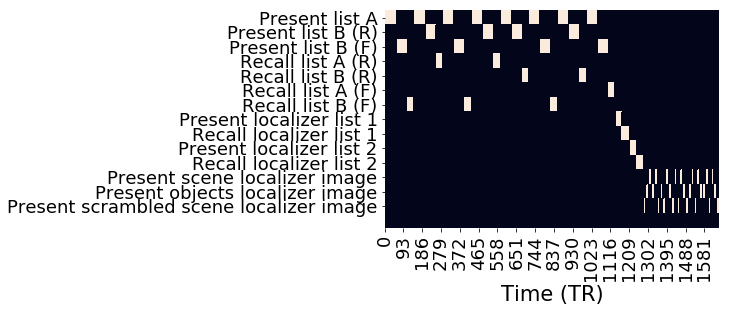

In [12]:
#experiment labels from participant 0
h = sns.heatmap(data[0]['regmat'], cbar=False)
h.set_yticks(np.arange(len(regressors_key)) + 0.5)
h.set_yticklabels(regressors_key)
plt.yticks(rotation=0);
plt.xlabel('Time (TR)');

In [13]:
def get_keys(inds):
    keys = []
    for i in inds:
        keys.append(regressors_key[i])
    return keys

In [14]:
print(get_keys(present_a))
print(get_keys(present_b))
print(get_keys(remember))
print(get_keys(forget))

['Present list A']
['Present list B (R)', 'Present list B (F)']
['Present list B (R)', 'Recall list A (R)', 'Recall list B (R)']
['Present list B (F)', 'Recall list A (F)', 'Recall list B (F)']


In [15]:
def get_bounds(x): #x is a line from a regressors matrix
    diffs = np.diff(np.array(x, dtype=np.float)) #strange things happen when x is an array of ints
    return np.where(diffs == 1)[0], np.where(diffs == -1)[0] #event starts, ends

In [16]:
def get_events(data, event_times, before=25, after=25):
    '''
    return the data, centered on each event_time. the resulting matrix is of shape
    (before + after + 1) by data.shape[1] by len(event_times).  if an event starts
    or ends too close to the beginning or end of the given data, the slice of that
    event's representation in the result will contain nans to reflect the missing
    data.
    '''
    
    x = np.multiply(np.nan, np.zeros([before + after + 1, data.shape[1], len(event_times)]))
    for i, t in enumerate(event_times):
        start_time = t - before - 1
        end_time = t + after
        
        if start_time >= 0:
            start_ind = 0
        else:
            start_ind = np.abs(start_time)
            start_time = 0
        
        if end_time <= data.shape[0]:
            end_ind = before + after + 1
        else:
            end_ind = end_time - data.shape[0]
            end_time = data.shape[0]
        
        x[start_ind:end_ind, :, i] = data[start_time:end_time, :]
    return x

In [17]:
def get_network_dynamics(x, rows, offset=0, before=50, after=50, **kwargs):
    def copier(a):
        if type(a) == list:
            return list(map(copier, a))
        return np.copy(a)
    
    if not (type(rows) == list):
        rows = [rows]
        delist = True
    else:
        delist = False
    
    nets = []
    for r in rows:
        next_data = list(map(lambda y: get_events(y['data'], get_bounds(y['regmat'][r, :])[0] + offset, before=before, after=after), x))
        next_means = list(map(lambda y: np.nanmean(y, axis=2), next_data))
        nets.append(tc.timecorr(copier(next_means), **kwargs))        
    if delist:
        return nets[0]
    else:
        return nets

In [18]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [19]:
def ribbon(x, y, lb, ub=None, color='k', alpha=0.5):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

In [20]:
def event_ribbon(x, ts=None, limit_t=None, color='k', alpha=0.5):
    if ts is None:
        ts = np.arange(-(x.shape[0] - 1)/2, (x.shape[0] - 1)/2 + 1) #assume centered data
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    x = x[inds, :]
    ts = ts[inds]
                
    m = np.nanmean(x, axis=1)
    ci = 1.96*np.divide(np.nanstd(x, axis=1), np.sqrt(x.shape[1])) # 95% confidence intervals
    
    return ribbon(ts, m, ci, ci, color=color, alpha=alpha)

In [21]:
buffer = 50
r_f_nets = get_network_dynamics(data, [1, 2], weights_function=kernel_weights, weights_params=kernel_params, before=buffer, after=buffer, offset=0, include_timepoints='pre', exclude_timepoints=10)


In [22]:
means = list(map(tc.corrmean_combine, r_f_nets))
diffs = list(map(lambda x, y: x - y, r_f_nets[0], r_f_nets[1]))
tvals, pvals = tc.tstat_combine(diffs, return_pvals=True)
filtered_tvals = np.multiply(tvals, (pvals < 0.0001/np.sum(np.isnan(pvals)))) #Bonferroni corrected p < 0.0001

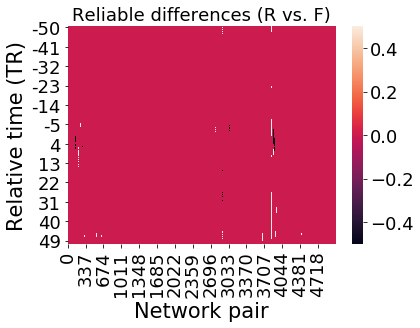

In [23]:
sns.heatmap(pd.DataFrame(np.multiply(tvals, (pvals < 0.05/np.sum(np.isnan(pvals)))), index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Reliable differences (R vs. F)');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

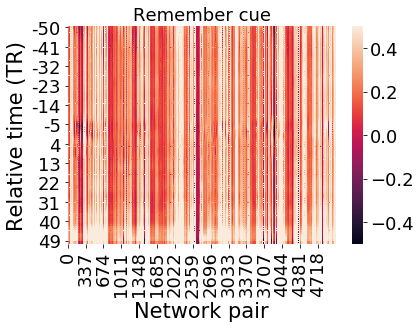

In [24]:
sns.heatmap(pd.DataFrame(means[0], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Remember cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

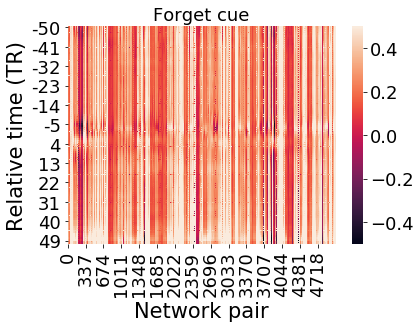

In [25]:
sns.heatmap(pd.DataFrame(means[1], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Forget cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

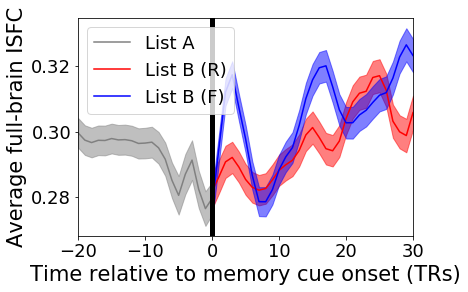

In [26]:
ts = np.arange(-buffer, buffer+1)
min_time = -20
max_time = 30

colors = [[0.5, 0.5, 0.5], 'r', 'b']
event_ribbon(np.mean(np.concatenate([means[0][:, :, np.newaxis], means[1][:, :, np.newaxis]], axis=2), axis=2), ts=ts, color=colors[0], limit_t=[min_time, 0]);
event_ribbon(means[0], ts=ts, color=colors[1], limit_t=[0, max_time]);
event_ribbon(means[1], ts=ts, color=colors[2], limit_t=[0, max_time]);
plt.legend(['List A', 'List B (R)', 'List B (F)'])


plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('Average full-brain ISFC')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 'ribbon_plot.pdf'))

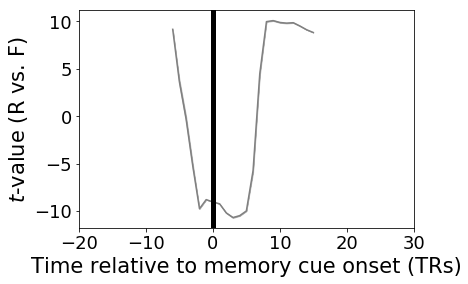

In [33]:
nanned_filtered_tvals = filtered_tvals
nanned_filtered_tvals[nanned_filtered_tvals == 0] = np.nan
event_ribbon(filtered_tvals, ts=ts, color=[0.5, 0.5, 0.5], limit_t=[min_time, max_time])
plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('$t$-value (R vs. F)')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 't_vals_timeseries.pdf'))

In [34]:
eng = mlab.start_matlab()

In [35]:
def mlab_array(x):    
    return matlab.double(x.tolist())

In [36]:
def BrainNet_animation(centers, widths, connections, outfile, ts=None, limit_t=None, force_refresh=False):
    if ts is None:
        ts = np.arange(connections.shape[2])
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    ts = ts[inds]
    connections = connections[:, :, inds]
    
    for i, t in enumerate(ts):
        next_fname = outfile + '_' + '{:03d}'.format(i) + '.jpg'
        if (not os.path.exists(next_fname)) or force_refresh:
            eng.TFA_BrainNet_wrapper(mlab_array(centers), mlab_array(widths), mlab_array(np.squeeze(connections[:, :, i])), next_fname, os.path.join('data', 'brainnet_config_DF.mat'), nargout=0)
                                            

In [37]:
BrainNet_animation(centers, widths, tc.vec2mat(filtered_tvals), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'diffs'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[0]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'remember'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[1]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'forget'), force_refresh=True)

In [44]:
eng.exit()

In [38]:
!ffmpeg -i {figdir}/diffs_%03d.jpg -c:v libx264 -r 25 {figdir}/diffs.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/diffs_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/u

In [42]:
!ffmpeg -i {figdir}/remember_%03d.jpg -c:v libx264 -r 25 {figdir}/remember.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/remember_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470b

In [43]:
!ffmpeg -i {figdir}/forget_%03d.jpg -c:v libx264 -r 25 {figdir}/forget.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/forget_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/